In [1]:
# %load header.py
from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.magic(u'matplotlib inline')

import matplotlib.pyplot as plt
import numpy as np
import os
import urllib
from astropy import constants as c
import dsharp_opac as opacity

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
def Bnu(lam, T):
    lam = lam*1e-2 # cgs to SI
    from scipy.constants.constants import c, k, h
    nu = c/lam
    exponent = h*nu/(k*T)
    return 2*h*nu**3/c**2 * 1./(np.exp(exponent)-1)

def F(tau, omega, mu):
    eps = np.sqrt(1.-omega)
    line1 = 1. / ( np.exp(-np.sqrt(3)*eps*tau)*(eps-1) - (eps+1) )
    line2 = (1-np.exp(-(np.sqrt(3)*eps+1./mu)*tau) ) / (np.sqrt(3)*eps*mu+1)
    line3 = (np.exp(-tau/mu) - np.exp(-np.sqrt(3)*eps*tau)) / (np.sqrt(3)*eps*mu - 1)
    
    return line1*(line2+line3)

def intensityoverplanck(tau, omega, mu):
    return (1-np.exp(-tau/mu)) + omega*F(tau, omega, mu)



/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 1.1e+11%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2e+11%: above error tolerance
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 2.4e+11%: above error tolerance
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/npz_files/dsharp_p0.99_smooth_extrapollargeamax.npz"

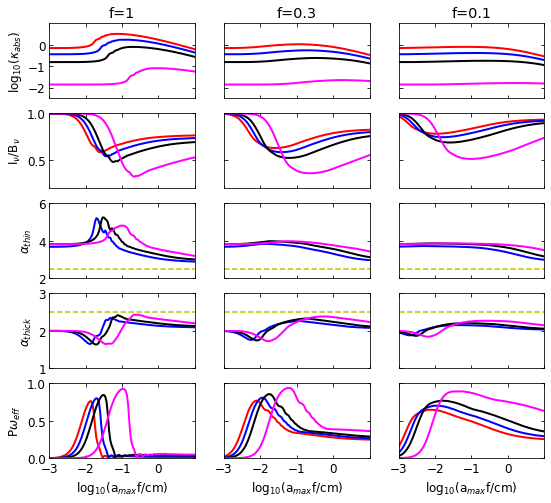

In [3]:
plt.figure(figsize=(12, 8))
colorcyc = [ 'r', 'b', 'k', 'magenta']
plt.rc("font", size=12)
obs_wavs = np.array([0.8740e-1, 1.287e-1, 2.141e-1, 7.889e-1])
mu = 1

linewidth=2

for j in range(4):
    
    prefix = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ZHANG_CODE/npz_files/"
    fnames = ["dsharp_p0.00_smooth_extrapol.npz", 
              "dsharp_p0.70_smooth_extrapol.npz",
              "dsharp_p0.90_smooth_extrapol.npz", 
              "dsharp_p0.99_smooth_extrapollargeamax.npz"] #this one is not available
    fillingfactors = [1, 0.3, 0.1, 0.01]

    d      = np.load(prefix+fnames[j])
    a      = d['a']
    lam    = d['lam']
    k_abs  = d['k_abs']
    k_sca  = d['k_sca']
    gsca   = d['g']
    rho_s  = d['rho_s']
    m   = 4 * np.pi / 3 * rho_s * a**3
    S1     = d['S1']
    S2     = d['S2']
    theta =  d['theta']
    g     =  d['g']
    # index where theta = 90 degree
    i90 = theta.searchsorted(90)
    zscat = opacity.calculate_mueller_matrix(lam, m, S1, S2, theta=theta, k_sca=k_sca)['zscat']


    # make a loop over the maximum particle size
    k_a = np.zeros_like(k_abs)
    k_s = np.zeros_like(k_sca)
    k_s_eff = np.zeros_like(k_sca)
    g_s = np.zeros_like(gsca)
    
    Z11eff = np.zeros([len(a), len(lam)])
    Z12eff = np.zeros_like(Z11eff)
    omega = np.zeros_like(Z11eff)
    omega_eff = np.zeros_like(Z11eff)
    
    for ia, _a in enumerate(a):

        # make a normalized MRN distribution

        distri = a**0.5
        distri[a > _a] = 0
        distri /= distri.sum()

        # average the opacities to get the average albedo

        k_a[ia] = np.sum(k_abs * distri[:, None], 0)
        k_s[ia] = np.sum(k_sca * distri[:, None], 0)
        #k_s_eff = k_s*(1-g_s)
        # The way caculate g here is wrong!!!        
        #g_s[ia] = np.sum(gsca * distri[:, None], 0)
        
        
        k_s_eff[ia] = np.sum(k_sca*(1-g) * distri[:, None], 0)
        
                # average the scattering matrix elements

        Z11eff[ia] = np.sum(zscat[:, :, i90, 0] * distri[:, None], 0)
        Z12eff[ia] = np.sum(zscat[:, :, i90, 1] * distri[:, None], 0)

        
    # calculate polarization fraction at 90 degree

    P = np.abs(Z12eff / Z11eff)
    
    chi = k_a + k_s_eff
    chi_iso = k_a + k_s
    omega = (k_s_eff)/(k_s_eff + k_a)
    omega_iso = (k_s_eff)/(k_s + k_a)
    
    
    

    
    plt.subplot(5, 4, 1+j)
    plt.title(f"f={fillingfactors[j]}")
    for i in range(4):
        idx1 = lam.searchsorted(obs_wavs[i])
        plt.plot(np.log10(a*fillingfactors[j]), np.log10(k_a[:, idx1]),
                 c=colorcyc[i],
                linewidth=linewidth)
    #plt.ylim(-5, -1)
    plt.xlim(-3, 1)
    plt.tick_params(labelbottom=0, direction='in',
                   bottom=True, top=True, left=True, right=True )
    if j==0:
        plt.ylabel(r"log$_{10}$($\kappa_{abs}$)")
        plt.yticks([-2, -1, 0])
    else:
        plt.tick_params(labelbottom=0, labelleft=0, direction='in',
                   bottom=True, top=True, left=True, right=True )
    plt.ylim(-4.5+2, -1+2)

    plt.subplot(5, 4, 5+j)
    for i in range(4):
        idx1 = lam.searchsorted(obs_wavs[i])
        reductionfactor = intensityoverplanck(1e10, omega[:, idx1], mu)
        plt.plot(np.log10(a*fillingfactors[j]), reductionfactor,
                 c=colorcyc[i],
                linewidth=linewidth)
    plt.ylim(0.2, 1.0)
    plt.xlim(-3, 1)
    plt.tick_params(labelbottom=0, direction='in',
                   bottom=True, top=True, left=True, right=True )
    if j==0:
        plt.ylabel(r"I$_{\nu}$/B$_{\nu}$")
    else:
        plt.tick_params(labelbottom=0, labelleft=0, direction='in',
                   bottom=True, top=True, left=True, right=True )

    plt.subplot(5, 4, 9+j)
    
    for i in range(3):
        idx1 = lam.searchsorted(obs_wavs[i])
        idx2 = lam.searchsorted(obs_wavs[i+1])
        sigmadtest = 1e-10
        reductionfactor1 = intensityoverplanck(sigmadtest*(k_a[:, idx1]+k_s_eff[:, idx1]), omega[:, idx1], mu)
        reductionfactor2 = intensityoverplanck(sigmadtest*(k_a[:, idx2]+k_s_eff[:, idx2]), omega[:, idx2], mu)
        beta_chi2D = (np.log(reductionfactor2) - np.log(reductionfactor1))/ (np.log(lam[idx1]) - np.log(lam[idx2]))
        plt.plot(np.log10(a*fillingfactors[j]), beta_chi2D+2, c=colorcyc[i+1],
                linewidth=linewidth)
    plt.tick_params(labelbottom=0, direction='in',
                   bottom=True, top=True, left=True, right=True )   
    plt.xlim(-3, 1)
    plt.ylim(2, 6)
    #plt.gca().get_yticklabels().set_visible(False)
    if j==0:
        plt.ylabel(r"$\alpha_{thin}$")
    else:
        plt.tick_params(labelbottom=0, labelleft=0, direction='in',
                   bottom=True, top=True, left=True, right=True ) 
    plt.axhline(2.5, linestyle='--', color='y')

    plt.subplot(5, 4, 13+j)
    for i in range(3):
        idx1 = lam.searchsorted(obs_wavs[i])
        idx2 = lam.searchsorted(obs_wavs[i+1])
        sigmadtest = 1e10
        reductionfactor1 = intensityoverplanck(sigmadtest*(k_a[:, idx1]+k_s_eff[:, idx1]), omega[:, idx1], mu)
        reductionfactor2 = intensityoverplanck(sigmadtest*(k_a[:, idx2]+k_s_eff[:, idx2]), omega[:, idx2], mu)
        beta_chi2D = (np.log(reductionfactor2) - np.log(reductionfactor1))/ (np.log(lam[idx1]) - np.log(lam[idx2]))
        plt.plot(np.log10(a*fillingfactors[j]), beta_chi2D+2, c=colorcyc[i+1],
                linewidth=linewidth)
    plt.ylim( 1, 3)
    plt.xlim(-3, 1)
    plt.tick_params( direction='in',
                   bottom=True, top=True, left=True, right=True, labelbottom=0 )
    plt.ylabel(r"$\alpha_{thick}$")
    if (j!=0):
        plt.tick_params( direction='in', labelbottom=0, labelleft=0,
                       bottom=True, top=True, left=True, right=True )
        plt.ylabel(None)
    #if (j!=3):
    #    plt.setp(plt.gca().get_xticklabels()[-1], visible=False)
    plt.axhline(2.5, linestyle='--', color='y')
    
    plt.subplot(5, 4, 17+j)
    for i in range(4):
        idx1 = lam.searchsorted(obs_wavs[i])
        plt.plot(np.log10(a*fillingfactors[j]), (P*omega)[:, idx1], c=colorcyc[i],
                linewidth=linewidth)
    plt.ylim( 0, 1)
    plt.xlim(-3, 1)
    plt.xlabel("log$_{10}$(a$_{max}$f/cm)")
    plt.tick_params( direction='in',
                   bottom=True, top=True, left=True, right=True )
    plt.ylabel(r"P$\omega_{eff}$")
    if (j!=0):
        plt.tick_params( direction='in', labelleft=0,
                       bottom=True, top=True, left=True, right=True )
        plt.ylabel(None)
    if (j!=3):
        plt.setp(plt.gca().get_xticklabels()[-1], visible=False)
    plt.axhline(2.5, linestyle='--', color='y')
        

plt.subplot(5, 4, 5)
plt.text(0.8, 0.1, "Thick", transform=plt.gca().transAxes)

plt.subplot(5, 4, 9)
plt.text(0.8, 0.1, "Thin", transform=plt.gca().transAxes)

plt.subplot(5, 4, 13)
plt.text(0.8, 0.1, "Thick", transform=plt.gca().transAxes)
    

#plt.setp(plt.gca().get_yticklabels()[4], visible=False)  
plt.subplot(5, 4, 13)
plt.setp(plt.gca().get_yticklabels()[-1], visible=False)  
#plt.setp(plt.gca().get_yticklabels()[3], visible=False)  

plt.subplot(5, 4, 17)
plt.setp(plt.gca().get_yticklabels()[-1], visible=False)  
#plt.setp(plt.gca().get_yticklabels()[4], visible=False)  

plt.subplots_adjust(hspace=0, wspace=0)

plt.subplot(5, 4, 8)
plt.text(0.05, 0.17, r"$\lambda$ = "+f"{obs_wavs[0]*10:1.2f}mm",
         transform=plt.gca().transAxes,
        color=colorcyc[0],
        fontsize=10)

plt.text(0.5, 0.17, r"$\lambda$ = "+f"{obs_wavs[1]*10:1.2f}mm",
         transform=plt.gca().transAxes,
        color=colorcyc[1],
        fontsize=10)

plt.text(0.05, 0.05, r"$\lambda$ = "+f"{obs_wavs[2]*10:1.2f}mm",
         transform=plt.gca().transAxes,
        color=colorcyc[2],
        fontsize=10)

plt.text(0.5, 0.05, r"$\lambda$ = "+f"{obs_wavs[3]*10:1.2f}mm",
         transform=plt.gca().transAxes,
        color=colorcyc[3],
        fontsize=10)

plt.subplot(5, 4, 12)
plt.text(0.05, 0.9, r"$\alpha$"+f"({obs_wavs[1]*10:1.2f} - {obs_wavs[0]*10:1.2f}mm)",
         transform=plt.gca().transAxes,
        color=colorcyc[1],
        fontsize=10)

plt.text(0.05, 0.76, r"$\alpha$"+f"({obs_wavs[2]*10:1.2f} - {obs_wavs[1]*10:1.2f}mm)",
         transform=plt.gca().transAxes,
        color=colorcyc[2],
        fontsize=10)

plt.text(0.05, 0.62, r"$\alpha$"+f"({obs_wavs[3]*10:1.2f} - {obs_wavs[2]*10:1.2f}mm)",
         transform=plt.gca().transAxes,
        color=colorcyc[3],
        fontsize=10)



# plt.savefig("porousFig9zhu19_Tazaki19.pdf", bbox_inches='tight', transparent=True)